# ANOVA

- T-test는 두 집단의 평균 차이를 검정하는 방법

- 세 집단 이상의 평균을 검정할 때는 ANOVA를 사용
    - T-test를 사용하여 세 집단 이상을 분석하고 싶다면 A와 B, B와 C, A와 C를 검정할 수 있음
    - 하지만 위의 방법은 신뢰도가 하락하는 문제가 있어 일반적으로 집단이 3개 이상일 때는 ANOVA를 사용

- ANOVA의 가설
    - H0(귀무가설) : 독립변수 차이에 따른 종속변수는 동일하다
    - H1(대립가설) : 독립변수 차이에 따른 종속변수는 다르다

- ANOVA는 독립변수의 수에 따라 다르게 불림
    - 예) 고객들의 객단가 평균 차이를 비교하기 위한 요인이 "지역" 하나라면 일원분산분석(one-way ANOVA)
    - 만약 요인이 "지역", "연령대" 두 가지라면 이원분산분석(two-way ANOVA), 더 많은 N가지라면 N원분산분석(N-way ANOVA)라고 함

- ANOVA를 사용할 때 독립변수는 집단을 나타낼 수 있는 범주형 변수여야 하며, 종속변수는 연속형 변수여야 함
    - 독립변수와 종속변수가 연속형일 때는 회귀분석
    - 독립변수와 종속변수가 범주형일 때는 교차분석

<img src="./image/anova_charts.jpg" >

- ANOVA는 각 집단의 평균의 분산이 큰 정도를 따져서 집단 간 평균이 다른 지 판별
    - 집단 내 관측치들이 집단 평균으로부터 얼마나 퍼져 있는 지를 나타내는 집단 내 분산
    - 전체 집단의 통합 평균과 각 집단의 평균값이 얼마나 퍼져 있는 지를 나타내는 집단 간 분산

- 집단 간 평균의 분산을 집단 내 분산으로 나눈 값이 유의도 임계치를 초과하는 지 여부에 따라 집단 간 평균의 차이를 검정

- ANOVA 분석의 결과만으로는 각 집단의 평균이 모두 다른 것인지 일부만 다른 것인지는 확인 불가능
    - 일부 집단들은 집단 간 차이가 없을 수 있음
    - 이러한 1종 오류(귀무가설이 참임에도 불구하고 귀무가설을 기각하는 오류)를 방지하기 위해 사후 검증을 수행

- 사후검증은 집단 크기가 같을 때 사용하는 Tukey의 HSD 검증, 집단의 크기가 다를 때 사용하는 scheffe 검증 방법 등 존재

In [1]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import pandas as pd

In [2]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

In [3]:
df = pd.read_csv("./data/csv/Golf_test.csv")

In [4]:
df.head()

,TypeA_before,TypeA_after,TypeB_before,TypeB_after,TypeC_before,TypeC_after
0,277,264,265,268,267,268
1,269,261,264,267,264,269
2,263,267,269,272,283,283
3,266,272,274,277,287,266
4,262,258,261,264,275,266


In [5]:
# stats 패키지 ANOVA 검정
stats.f_oneway(df["TypeA_before"], df["TypeB_before"], df["TypeC_before"])

F_onewayResult(statistic=np.float64(4.220169433030091), pvalue=np.float64(0.016515420191903243))

- 정규성 검정과 등분산 검증은 앞서 수행했으므로 생략

- pvalue가 0.05보다 작으므로 3개 집단 중 최소한 하나의 집단은 통계적으로 유의미한 차이가 있음

In [6]:
# ols 패키지 사용을 위한 전처리
df2 = pd.melt(df)
df2.head()

,variable,value
0,TypeA_before,277
1,TypeA_before,269
2,TypeA_before,263
3,TypeA_before,266
4,TypeA_before,262


In [8]:
df2 = df2[df2["variable"].isin(["TypeA_before", "TypeB_before", "TypeC_before"])]

In [9]:
df2.head()

,variable,value
0,TypeA_before,277
1,TypeA_before,269
2,TypeA_before,263
3,TypeA_before,266
4,TypeA_before,262


- 각 골프공 조건이 개별 컬럼으로 구성되어 있기 때문에 variable 컬럼과 value 컬럼으로 재구조화

In [10]:
# ols 패키지 ANOVA 검정
model = ols("value ~ C(variable)", df2).fit()
print(anova_lm(model))

                df        sum_sq     mean_sq         F    PR(>F)
C(variable)    2.0    675.453333  337.726667  4.220169  0.016515
Residual     147.0  11763.940000   80.026803       NaN       NaN


- 앞서 수행한 ANOVA 검정과 동일한 결과

- 데이터셋의 형태에 따라 사용하기 편한 패키지를 선택하면 됨

      Multiple Comparison of Means - Tukey HSD, FWER=0.50       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
TypeA_before TypeB_before     5.14 0.0129  3.1265  7.1535   True
TypeA_before TypeC_before      1.9 0.5392 -0.1135  3.9135  False
TypeB_before TypeC_before    -3.24 0.1696 -5.2535 -1.2265   True
----------------------------------------------------------------


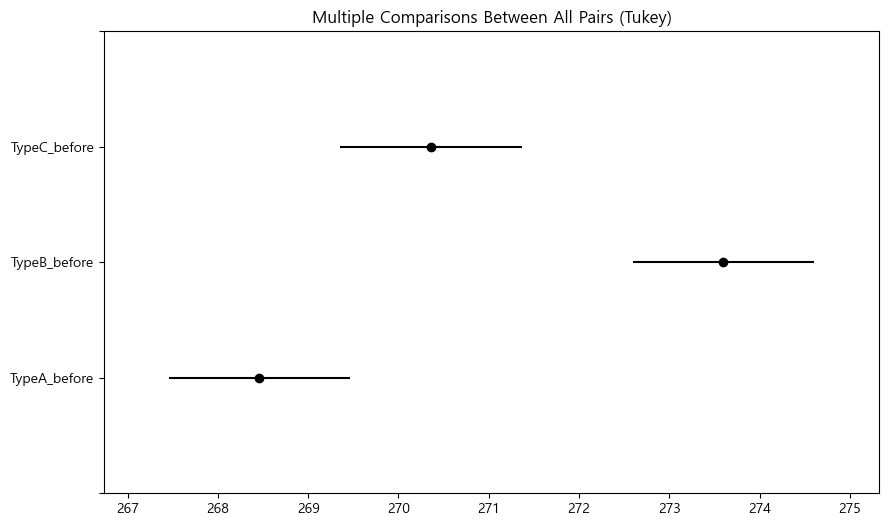

In [11]:
# 사후검정
posthoc = pairwise_tukeyhsd(df2["value"], df2["variable"], alpha = 0.5)
print(posthoc)
fig = posthoc.plot_simultaneous()

- Tukey의 HSD 사후검정을 수행

- TypeA_before와 TypeB_before 간에만 유의미한 차이가 있고, 나머지 조합에서는 통게적으로 유의미한 차이가 없음